# 04 — Strategic Context & Competitive Positioning

## Objective
Synthesise findings from notebooks 01–03 into a strategic view of the competitive landscape. Identify which business models exist in the market, map brand positioning by price and age focus, and assess where the structural gap sits.

This notebook draws on:
- **Notebook 01** — competitor pricing data (19 brands, UK and US)
- **Notebook 02** — search behaviour and discovery channels
- **Notebook 03** — social media scale, engagement, and platform balance

---

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')

COLOURS = {
    'uk_mass':     '#78909C',
    'uk_mid':      '#5C7A9F',
    'uk_lifestyle':'#8E6BAD',
    'uk_premium':  '#2E5FA3',
    'us_premium':  '#E8A838',
    'gap':         '#C0392B',
}

print('Ready')

Ready


---
## Section 1: Strategic Models Identified

From the 21 brands analysed across notebooks 01–03, four distinct business/social models emerge in the kids and teen sleepwear space.

In [2]:
models_data = [
    {
        'Model': 'Traditional premium',
        'Brands': 'Desmond & Dempsey, Petite Plume',
        'Approach': 'Editorial aesthetic, influencer UGC, likes often hidden',
        'Relevance': 'Quality and brand-world benchmark — but stops at age 10'
    },
    {
        'Model': 'Accessible premium',
        'Brands': 'Roller Rabbit, Boden',
        'Approach': 'Premium social presence + mass distribution (e.g. Target collabs)',
        'Relevance': 'Volume strategy — proves premium kids PJs sell, but kids-focused not teen'
    },
    {
        'Model': 'Algorithm-first / DTC',
        'Brands': 'White Fox, Lounge',
        'Approach': 'High-frequency posting, volume-led content, strong brand identity',
        'Relevance': 'Proves identity-led DTC can scale — but adult audience, not kids/teen'
    },
    {
        'Model': 'TikTok-native founder',
        'Brands': 'Pink Palm Puff',
        'Approach': 'Founder IS the influencer, viral drops, no traditional marketing',
        'Relevance': 'Primary reference model — closest to the teen sleepwear opportunity'
    }
]

df_models = pd.DataFrame(models_data)
df_models.style.set_properties(**{'text-align': 'left'})

,Model,Brands,Approach,Relevance
0,Traditional premium,"Desmond & Dempsey, Petite Plume","Editorial aesthetic, influencer UGC, likes often hidden",Quality and brand-world benchmark — but stops at age 10
1,Accessible premium,"Roller Rabbit, Boden",Premium social presence + mass distribution (e.g. Target collabs),"Volume strategy — proves premium kids PJs sell, but kids-focused not teen"
2,Algorithm-first / DTC,"White Fox, Lounge","High-frequency posting, volume-led content, strong brand identity","Proves identity-led DTC can scale — but adult audience, not kids/teen"
3,TikTok-native founder,Pink Palm Puff,"Founder IS the influencer, viral drops, no traditional marketing",Primary reference model — closest to the teen sleepwear opportunity


### Commentary

Each model demonstrates that a component of the opportunity works — premium kids sleepwear sells (Roller Rabbit, D&D), identity-led DTC brands can build scale on social (White Fox, Lounge), and TikTok-native content can drive explosive growth in teen apparel (Pink Palm Puff). No single brand currently combines all three: premium positioning + teen-specific identity + TikTok-native discovery.

---
## Section 2: Competitive Positioning Map

Plotting brands by average price point (x-axis) against the midpoint of their target age range (y-axis). Data sourced from the competitor pricing CSV (notebook 01).

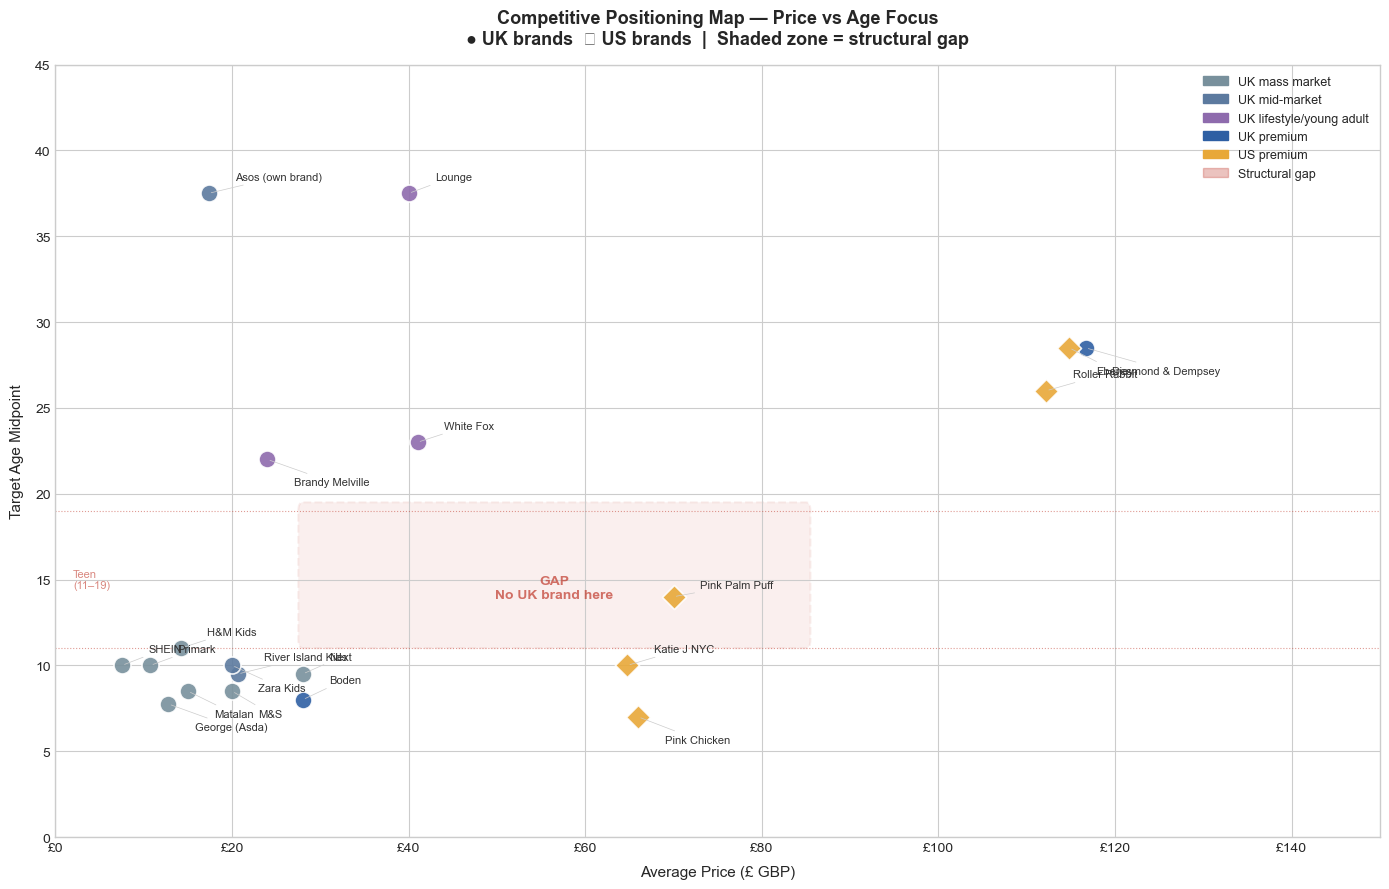

In [3]:
# Load pricing data from notebook 01
df_prices = pd.read_csv(Path('..') / '01_competitor_analysis' / 'data' / 'competitor_prices_all.csv')

# Calculate per-brand: average price, age range midpoint
brand_pos = df_prices.groupby(['brand', 'market']).agg(
    avg_price=('price_gbp', 'mean'),
    min_age=('min_age', 'min'),
    max_age=('max_age', 'max')
).reset_index()
brand_pos['mid_age'] = (brand_pos['min_age'] + brand_pos['max_age']) / 2

# Manual overrides for brands with split demographics (kids + adult lines).
# Calculated midpoint misrepresents their core positioning.
# Pink Chicken: core identity is kids-focused (2–12); adult line is secondary.
# Roller Rabbit: core identity is adult-focused; kids line is an extension.
brand_pos.loc[brand_pos['brand'] == 'Pink Chicken', 'mid_age'] = 7
brand_pos.loc[brand_pos['brand'] == 'Roller Rabbit', 'mid_age'] = 26

# Assign colours by segment
uk_mass = ['SHEIN', 'George (Asda)', 'Primark', 'H&M Kids', 'Matalan', 'M&S', 'Next']
uk_mid = ['Zara Kids', 'River Island Kids', 'Asos (own brand)']
uk_lifestyle = ['Brandy Melville', 'White Fox', 'Lounge']
uk_premium = ['Boden', 'Desmond & Dempsey']
us_brands = ['Katie J NYC', 'Pink Chicken', 'Roller Rabbit', 'Eberjey', 'Posh Peanut']

def get_colour(brand, market):
    if market == 'US': return COLOURS['us_premium']
    if brand in uk_mass: return COLOURS['uk_mass']
    if brand in uk_mid: return COLOURS['uk_mid']
    if brand in uk_lifestyle: return COLOURS['uk_lifestyle']
    if brand in uk_premium: return COLOURS['uk_premium']
    return '#999999'

brand_pos['colour'] = brand_pos.apply(lambda r: get_colour(r['brand'], r['market']), axis=1)

# Plot
fig, ax = plt.subplots(figsize=(14, 9))

# Gap zone shading — teen ages (11–19) × prices above mass-market ceiling
gap_rect = mpatches.FancyBboxPatch((28, 11.5), 57, 7.5, boxstyle='round,pad=0.5',
                                     facecolor=COLOURS['gap'], alpha=0.08, edgecolor=COLOURS['gap'],
                                     linewidth=1.5, linestyle='--', zorder=0)
ax.add_patch(gap_rect)
ax.text(56.5, 14.5, 'GAP\nNo UK brand here', ha='center', va='center',
        fontsize=10, fontweight='bold', color=COLOURS['gap'], alpha=0.7)

# Scatter
for _, row in brand_pos.iterrows():
    marker = 'o' if row['market'] == 'UK' else 'D'
    ax.scatter(row['avg_price'], row['mid_age'], s=150, c=row['colour'],
              marker=marker, edgecolors='white', linewidths=1.2, zorder=3, alpha=0.9)

# Labels
label_offsets = {
    'M&S':                (3, -1.5),
    'Next':               (3, 0.8),
    'Boden':              (3, 1),
    'Desmond & Dempsey':  (3, -1.5),
    'White Fox':          (3, 0.8),
    'Brandy Melville':    (3, -1.5),
    'Lounge':             (3, 0.8),
    'H&M Kids':           (3, 0.8),
    'Zara Kids':          (3, -1.5),
    'River Island Kids':  (3, 0.8),
    'Primark':            (3, 0.8),
    'George (Asda)':      (3, -1.5),
    'SHEIN':              (3, 0.8),
    'Matalan':            (3, -1.5),
    'Katie J NYC':        (3, 0.8),
    'Pink Chicken':       (3, -1.5),
    'Roller Rabbit':      (3, 0.8),
    'Eberjey':            (3, -1.5),
    'Asos (own brand)':   (3, 0.8),
}

for _, row in brand_pos.iterrows():
    ox, oy = label_offsets.get(row['brand'], (3, 0.5))
    ax.annotate(row['brand'], xy=(row['avg_price'], row['mid_age']),
                xytext=(row['avg_price'] + ox, row['mid_age'] + oy),
                fontsize=8, color='#333333',
                arrowprops=dict(arrowstyle='-', color='#cccccc', lw=0.5))

# Reference lines
ax.axhline(11, color=COLOURS['gap'], lw=0.8, ls=':', alpha=0.5)
ax.axhline(19, color=COLOURS['gap'], lw=0.8, ls=':', alpha=0.5)
ax.text(2, 15, 'Teen\n(11–19)', fontsize=8, color=COLOURS['gap'], alpha=0.6, va='center')

ax.set_xlabel('Average Price (£ GBP)', fontsize=11, labelpad=8)
ax.set_ylabel('Target Age Midpoint', fontsize=11, labelpad=8)
ax.set_title('Competitive Positioning Map — Price vs Age Focus\n'
             '● UK brands  ◆ US brands  |  Shaded zone = structural gap',
             fontsize=13, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('£%d'))
ax.set_xlim(0, 150)
ax.set_ylim(0, 45)

legend_items = [
    mpatches.Patch(color=COLOURS['uk_mass'], label='UK mass market'),
    mpatches.Patch(color=COLOURS['uk_mid'], label='UK mid-market'),
    mpatches.Patch(color=COLOURS['uk_lifestyle'], label='UK lifestyle/young adult'),
    mpatches.Patch(color=COLOURS['uk_premium'], label='UK premium'),
    mpatches.Patch(color=COLOURS['us_premium'], label='US premium'),
    mpatches.Patch(color=COLOURS['gap'], alpha=0.3, label='Structural gap'),
]
ax.legend(handles=legend_items, loc='upper right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

### Chart Commentary — Competitive Positioning Map

This chart plots every brand in the dataset by its average price point against its core target age positioning. The shaded zone marks the structural gap identified across notebooks 01–03.

**UK mass-market brands** (grey) cluster in the bottom-left: low prices (£6–33), kids-focused (age midpoint ~8–11). They serve the functional end of the market with no teen-specific identity.

**UK lifestyle brands** (purple) sit at higher price points but target adults and older teens (age midpoint 22–37). Brandy Melville is the closest to the gap zone but doesn't offer sleepwear.

**US premium brands** (gold diamonds) are the most instructive. Katie J NYC and Pink Chicken both sit in the kids zone at premium price points — validating that parents will pay £44–75 for quality kids sleepwear. Pink Palm Puff is the only brand that sits inside the gap zone — a US, TikTok-native brand serving tweens/teens at £70 with no UK equivalent. Roller Rabbit and Eberjey sit higher, reflecting their adult-first positioning.

**The gap (shaded red):** No UK brand positions in the teen age range (11–19) at a price point above the mass-market ceiling (~£33). The only brand occupying this space is Pink Palm Puff — a US brand discovered entirely through TikTok. This reinforces both the positioning gap and the channel gap identified in notebooks 02–03.

**Note on age positioning:** Brands with both kids and adult lines (Pink Chicken, Roller Rabbit, Boden, D&D) are plotted at their core demographic midpoint rather than a simple average across all products, to reflect actual brand positioning.

### Chart 2 · Kids & Teens Only — Positioning Map (Adults Excluded)

Same data, filtered to kids, teen, and young adult demographics only. Adult product lines from Roller Rabbit, Eberjey, Desmond & Dempsey, Pink Chicken, Lounge, and ASOS are excluded to show the kids/teen landscape clearly.

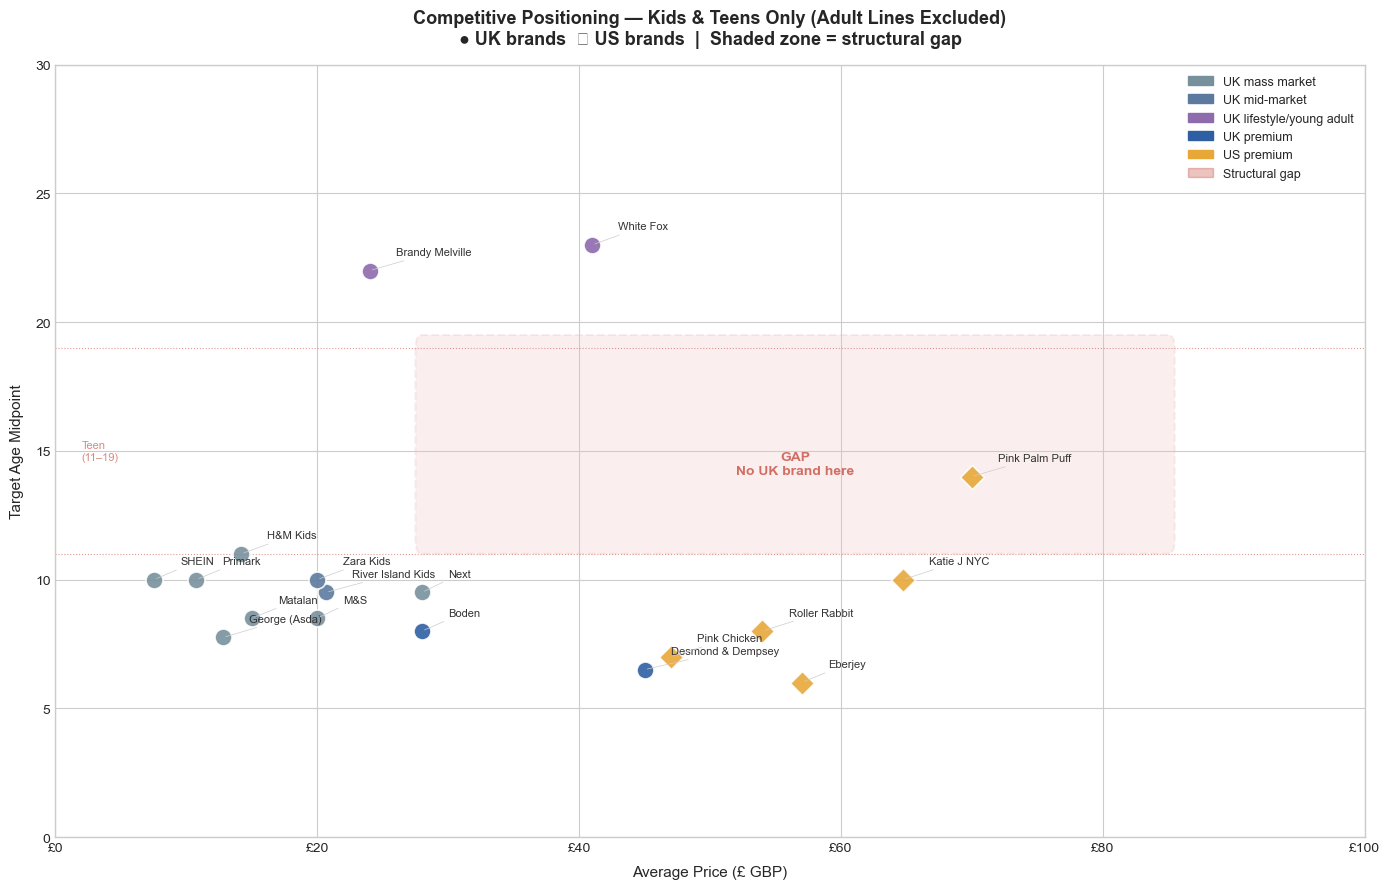

In [4]:
# Filter to non-adult demographics only
df_young = df_prices[df_prices['demographic'].isin(['Kids', 'Kids/Teen', 'Teen', 'Young Adult'])].copy()

# Calculate per-brand: average price, age range midpoint (kids/teen products only)
brand_young = df_young.groupby(['brand', 'market']).agg(
    avg_price=('price_gbp', 'mean'),
    min_age=('min_age', 'min'),
    max_age=('max_age', 'max')
).reset_index()
brand_young['mid_age'] = (brand_young['min_age'] + brand_young['max_age']) / 2

# Manual overrides for core positioning (same logic as Chart 1)
brand_young.loc[brand_young['brand'] == 'Pink Chicken', 'mid_age'] = 7

brand_young['colour'] = brand_young.apply(lambda r: get_colour(r['brand'], r['market']), axis=1)

fig, ax = plt.subplots(figsize=(14, 9))

# Gap zone shading — same as Chart 1
gap_rect = mpatches.FancyBboxPatch((28, 11.5), 57, 7.5, boxstyle='round,pad=0.5',
                                     facecolor=COLOURS['gap'], alpha=0.08, edgecolor=COLOURS['gap'],
                                     linewidth=1.5, linestyle='--', zorder=0)
ax.add_patch(gap_rect)
ax.text(56.5, 14.5, 'GAP\nNo UK brand here', ha='center', va='center',
        fontsize=10, fontweight='bold', color=COLOURS['gap'], alpha=0.7)

# Scatter
for _, row in brand_young.iterrows():
    marker = 'o' if row['market'] == 'UK' else 'D'
    ax.scatter(row['avg_price'], row['mid_age'], s=150, c=row['colour'],
              marker=marker, edgecolors='white', linewidths=1.2, zorder=3, alpha=0.9)

# Labels
for _, row in brand_young.iterrows():
    ax.annotate(row['brand'], xy=(row['avg_price'], row['mid_age']),
                xytext=(row['avg_price'] + 2, row['mid_age'] + 0.6),
                fontsize=8, color='#333333',
                arrowprops=dict(arrowstyle='-', color='#cccccc', lw=0.5))

# Reference lines
ax.axhline(11, color=COLOURS['gap'], lw=0.8, ls=':', alpha=0.5)
ax.axhline(19, color=COLOURS['gap'], lw=0.8, ls=':', alpha=0.5)
ax.text(2, 15, 'Teen\n(11–19)', fontsize=8, color=COLOURS['gap'], alpha=0.6, va='center')

ax.set_xlabel('Average Price (£ GBP)', fontsize=11, labelpad=8)
ax.set_ylabel('Target Age Midpoint', fontsize=11, labelpad=8)
ax.set_title('Competitive Positioning — Kids & Teens Only (Adult Lines Excluded)\n'
             '● UK brands  ◆ US brands  |  Shaded zone = structural gap',
             fontsize=13, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('£%d'))
ax.set_xlim(0, 100)
ax.set_ylim(0, 30)

legend_items = [
    mpatches.Patch(color=COLOURS['uk_mass'], label='UK mass market'),
    mpatches.Patch(color=COLOURS['uk_mid'], label='UK mid-market'),
    mpatches.Patch(color=COLOURS['uk_lifestyle'], label='UK lifestyle/young adult'),
    mpatches.Patch(color=COLOURS['uk_premium'], label='UK premium'),
    mpatches.Patch(color=COLOURS['us_premium'], label='US premium'),
    mpatches.Patch(color=COLOURS['gap'], alpha=0.3, label='Structural gap'),
]
ax.legend(handles=legend_items, loc='upper right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

### Chart Commentary — Kids & Teens Positioning (Adults Excluded)

With adult product lines stripped out, the kids/teen landscape becomes much clearer.

**UK mass-market cluster (£6–33, ages 8–14):** Unchanged — these brands dominate the volume end with no teen identity.

**US premium kids brands now visible at their true positions:** Roller Rabbit kids (£54), Eberjey kids (£57), Pink Chicken (£44–50), and D&D kids (£45) all sit in the £44–57 range at ages 6–10. This cluster confirms that premium kids sleepwear is an established, validated category — multiple brands have proven parents will pay £44–57 for quality kids PJs. But every one of them stops before the teen segment.

**The teen gap is even more visible.** With adult brands removed, the only occupant of the teen zone above mass-market pricing is Pink Palm Puff — a US, TikTok-native brand at £70. Katie J NYC sits just below at age ~10. Brandy Melville and White Fox remain in the young adult zone but without sleepwear focus.

**Limitation — sleepwear as standalone category:** PPP and Katie J NYC validate premium pricing for teen apparel brands, but neither is sleepwear-only. PPP's core product is hoodies; pyjamas are a secondary line. Katie J NYC is a full kidswear brand. Whether consumers will pay premium prices for a standalone teen sleepwear brand is an untested hypothesis. D&D validates premium sleepwear as a category; the open question is whether the teen demographic specifically supports it. Supporting signals include D&D kids at £45 (parents already pay premium for kids sleepwear), the strong 'matching family PJs' search trend (notebook 02), and the Christmas gifting behaviour that drives the category (gifting supports higher price points than self-purchase).

---
## Section 3: Adjacent Brands

Brands not included in the core 21-brand dataset but relevant to the competitive picture. These brands touch the teen and/or sleepwear space without directly occupying the identified gap.

In [5]:
adjacent_data = [
    {'Brand': 'Pull & Bear', 'Category': 'Fast fashion teen', 'Relevance': 'Proves 11–19 buys loungewear — but at £15–25, not premium'},
    {'Brand': 'Skinnydip London', 'Category': 'UK teen accessories/nightwear', 'Relevance': 'Teen-coded brand; PJ sets ~£22–38, playful/character-driven aesthetic'},
    {'Brand': 'Hanna Andersson', 'Category': 'US premium kids sleepwear', 'Relevance': 'Strong in matching family PJs — validates premium kids sleepwear at scale in US'},
    {'Brand': 'Adanola', 'Category': 'UK premium adult activewear/nightwear', 'Relevance': 'Closest UK social-first DTC comp — strong IG, high revenue, includes nightwear'},
    {"Brand": "Nobody's Child", 'Category': 'UK sustainable adult womenswear', 'Relevance': 'Shows UK appetite for ethical premium — adult women only'},
    {'Brand': 'Ava & Bear London', 'Category': 'UK premium kids sleepwear', 'Relevance': 'Confirms premium kids PJ market exists in UK — stops at ~age 10'},
]

df_adjacent = pd.DataFrame(adjacent_data)
df_adjacent.style.set_properties(**{'text-align': 'left'})

,Brand,Category,Relevance
0,Pull & Bear,Fast fashion teen,"Proves 11–19 buys loungewear — but at £15–25, not premium"
1,Skinnydip London,UK teen accessories/nightwear,"Teen-coded brand; PJ sets ~£22–38, playful/character-driven aesthetic"
2,Hanna Andersson,US premium kids sleepwear,Strong in matching family PJs — validates premium kids sleepwear at scale in US
3,Adanola,UK premium adult activewear/nightwear,"Closest UK social-first DTC comp — strong IG, high revenue, includes nightwear"
4,Nobody's Child,UK sustainable adult womenswear,Shows UK appetite for ethical premium — adult women only
5,Ava & Bear London,UK premium kids sleepwear,Confirms premium kids PJ market exists in UK — stops at ~age 10


### Commentary

Each adjacent brand confirms a piece of the opportunity without occupying the full position:
- **Teen demand exists** (Pull & Bear, Skinnydip) — but at mass-market or playful price points, not premium identity-led
- **Premium kids sleepwear works** (Hanna Andersson, Ava & Bear) — but both stop before the teen segment
- **UK social-first DTC can scale** (Adanola, Nobody's Child) — but both target adult women, not teens

No adjacent brand combines all three: premium positioning + teen-specific identity + sleepwear focus.

---
## Section 4: Key Synthesis

### The Gap in Context

Evidence from notebooks 01–03 converges on the same structural finding:

| Source | Finding |
|--------|--------|
| **Pricing (01)** | UK mass market caps at ~£33 for kids/teen sleepwear (Next ceiling). No UK brand serves teens between £33 and D&D kids at £45. US brands (Katie J NYC, PPP, Pink Chicken) validate premium pricing for this demographic. |
| **Search (02)** | Consumers search generic terms (`kids pyjamas`, `girls pyjamas`). No premium brand appears in top queries. Premium is discovered via social, not search. |
| **Social (03)** | Engagement inverts with scale. TikTok is underutilised by UK premium brands. Pink Palm Puff proves the TikTok-native model works for teen apparel. |
| **Positioning (this notebook)** | The teen age range (11–19) above mass-market pricing is structurally empty in the UK. PPP is the only brand inside the gap — and it's US-only. |

### What this means

The opportunity is not a single gap but a convergence of three:
1. **Positioning gap:** No UK brand sits at the intersection of teen age focus (11–19) + sleepwear category + price above mass-market ceiling (~£33). The price gap itself is narrow (£33–45), but the positioning gap is wide — no brand combines teen identity with premium sleepwear at any price.
2. **Identity gap:** UK brands either serve kids generically (M&S, Next) or adults exclusively (White Fox, Lounge). No brand offers teen-specific aesthetic positioning in sleepwear.
3. **Channel gap:** TikTok is the primary discovery platform for the target demographic, yet no UK sleepwear brand has meaningful TikTok presence.

A brand that occupies the intersection of these three gaps — accessible premium pricing, teen-specific identity, TikTok-native content — would face no direct UK competition. Pink Palm Puff demonstrates the model works; it simply hasn't been replicated in the UK.

---

*Next: Notebook 05 — Market Opportunity (demographic sizing, demand quantification)*